## orflib Library Examples

In [8]:
import orflib as orf
import numpy as np
import os
import matplotlib.pyplot as plt
plt.style.use('ggplot')

print("orflib version: {0}".format(orf.version()))
print("pid: {0}".format(os.getpid()))

orflib version: 0.8.0-debug
pid: 10762


# Q1

In [9]:
ycname = "USD"
yc = orf.ycCreate(ycname = ycname, 
                  tmats = [2], 
                  vals =  [0.04],
                  valtype = 0)
print(f'Created yield curve: {yc}')

Created yield curve: USD


In [10]:
vol_maturities = [1, 2]  
vol_values = [0.40, 0.60]  
volts_handle = orf.volCreate("VOLTS", vol_maturities, vol_values, 0) 

In [11]:
PDE = dict()
PDE["NTIMESTEPS"] = 800
PDE["NSPOTNODES"] = 800
PDE["NSTDDEVS"] = 5
PDE["THETA"] = 1
price_1 = orf.euroBSPDE(-1, 100.0, 1.0, 100.0, "USD", 0.0, "VOLTS", PDE, False)['Price']

PDE["THETA"] = 0.5
price_2 = orf.euroBSPDE(-1, 100.0, 1.0, 100.0, "USD", 0.0, "VOLTS", PDE, False)['Price']

In [12]:
# Price using the volatility handle (already calculated)
print("Price using volatility handle 'VOLTS':")
print(f"THETA = 1.0: {price_1:.6f}")
print(f"THETA = 0.5: {price_2:.6f}\n")

# Price using the numerical volatility value (0.60 for 2-year expiry)
PDE["THETA"] = 1.0
price_1_num = orf.euroBSPDE(-1, 100.0, 1.0, 100.0, "USD", 0.0, 0.40, PDE, False)['Price']
PDE["THETA"] = 0.5
price_2_num = orf.euroBSPDE(-1, 100.0, 1.0, 100.0, "USD", 0.0, 0.40, PDE, False)['Price']

print("Price using numerical volatility 0.60:")
print(f"THETA = 1.0: {price_1_num:.6f}")
print(f"THETA = 0.5: {price_2_num:.6f}\n")

print("Differences (handle - numerical):")
print(f"THETA = 1.0: {price_1 - price_1_num:.6f}")
print(f"THETA = 0.5: {price_2 - price_2_num:.6f}")

Price using volatility handle 'VOLTS':
THETA = 1.0: 13.654664
THETA = 0.5: 13.656929

Price using numerical volatility 0.60:
THETA = 1.0: 13.654664
THETA = 0.5: 13.656929

Differences (handle - numerical):
THETA = 1.0: 0.000000
THETA = 0.5: 0.000000


# Q2

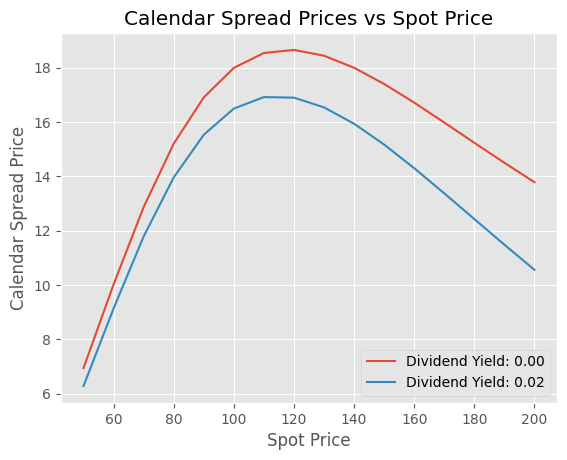

In [13]:
dividend_yields = [0, 0.02]  
spot = [50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200]
calendars = dict()
for div_yield in dividend_yields:
    for s in spot:
        price_long = orf.euroBSPDE(1,100,2,s,"USD",div_yield,"VOLTS",PDE, False)['Price']
        price_short = orf.euroBSPDE(1,100,1,s,"USD",div_yield,"VOLTS",PDE, False)['Price']
        calendar_price = price_long - price_short
        calendars[(div_yield, s)] = calendar_price

#Plot the calendar spreads
for div_yield in dividend_yields:
    spreads = [calendars[(div_yield, s)] for s in spot]
    plt.plot(spot, spreads, label=f'Dividend Yield: {div_yield:.2f}') 
plt.xlabel('Spot Price')
plt.ylabel('Calendar Spread Price')
plt.title('Calendar Spread Prices vs Spot Price')
plt.legend()
plt.show() 

Note how the increasing dividend yield asymmetrically suppresses the calendar spread price

# Q3

Digital Call Option Black-Scholes Price: 0.518661

Digital Call Option Price with 25 time steps: 0.442301, Difference from Black-Scholes: -0.076360
Digital Call Option Price with 50 time steps: 0.480519, Difference from Black-Scholes: -0.038142
Digital Call Option Price with 100 time steps: 0.499520, Difference from Black-Scholes: -0.019141
Digital Call Option Price with 200 time steps: 0.509064, Difference from Black-Scholes: -0.009597
Digital Call Option Price with 400 time steps: 0.513855, Difference from Black-Scholes: -0.004806
Digital Call Option Price with 800 time steps: 0.516256, Difference from Black-Scholes: -0.002405


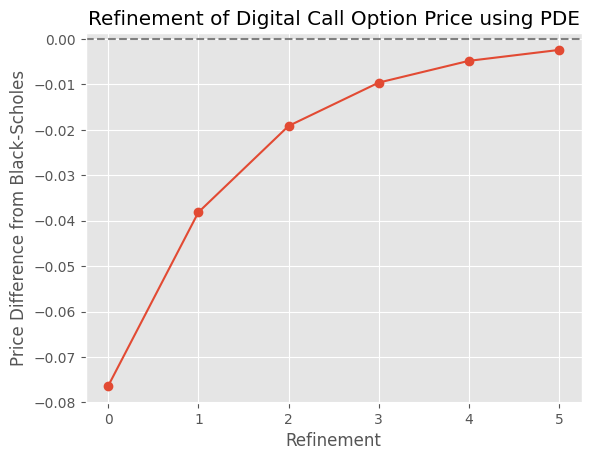

In [14]:
price_bs = orf.digiBS(-1, 100.0, 100.0, 1, 0.04, 0.0, 0.40)[0]
print(f"Digital Call Option Black-Scholes Price: {price_bs:.6f}\n")

refinement = []
for n in [25, 50, 100, 200, 400, 800]:
    PDE["NTIMESTEPS"] = n
    PDE["NSPOTNODES"] = n
    PDE["NSTDDEVS"] = 5.0
    PDE["THETA"] = 0.5
    price_n = orf.digiBSPDE(-1, 100.0, 1.0, 100.0, "USD", 0.0, "VOLTS", PDE, False)['Price']
    print(f"Digital Call Option Price with {n} time steps: {price_n:.6f}, Difference from Black-Scholes: {price_n - price_bs:.6f}")
    refinement.append((n, price_n, price_n - price_bs))

# Plot refinement against index
errors = [r[2] for r in refinement]
plt.plot(range(len(errors)), errors, marker='o')
plt.xlabel("Refinement")
plt.ylabel("Price Difference from Black-Scholes")
plt.title("Refinement of Digital Call Option Price using PDE")
plt.axhline(0, color='gray', linestyle='--')
plt.show()


This graph has refinements increasing by a factor of 2 and our erro seems to half at every step.
Thus we have LINEAR scaling in this plot of our error.